In [1]:
from profiling_and_attack import mlp_eshard, information, cnn, cnn_ASCAD, mlp
from utils import *
from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

2025-05-15 15:00:59.621429: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-15 15:00:59.640375: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-15 15:00:59.640402: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-15 15:00:59.641083: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-15 15:00:59.645023: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model
def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result

In [3]:
dataset_id = 'ascad-variable'
resample_window=80
traces_dim = 2000

n_prof= 100000
import gc

lm = "ID"
target_byte = 2
path = "./datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)

# Initialize SBox in objects as these are not loaded in default dataset.
sbox_ins = (dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


## Training model and plotting PI evolution

In [ ]:
import gc

n_epochs = 100
batch_size=400
model = cnn_ASCAD(256,traces_dim)
# Prefix for model loading. 
model_name = f"cnn_ascadr"


2025-05-08 10:25:49.308783: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-08 10:25:49.430027: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-08 10:25:49.430071: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-08 10:25:49.431619: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-08 10:25:49.431654: I external/local_xla/xla/stream_executor

Model: "cnn_search"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 2000, 1)]         0         
                                                                 
 conv_1 (Conv1D)             (None, 134, 12)           492       
                                                                 
 bn_1 (BatchNormalization)   (None, 134, 12)           48        
                                                                 
 average_pooling1d (Average  (None, 67, 12)            0         
 Pooling1D)                                                      
                                                                 
 conv_2 (Conv1D)             (None, 5, 24)             11544     
                                                                 
 bn_2 (BatchNormalization)   (None, 5, 24)             96        
                                                        

KeyboardInterrupt: 

In [ ]:
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    # Reload the model and its weights
    #layer = layers
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")

    # Extract the outputs of all layers and store them in tmp/tmp_att
    outputs = [model.layers[layer].output if layer > 0 else [] for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()

# Reload the model and its weights if only output is needed (e.g., for model evaluation)
def only_reload(epoch):
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")
probes_for_bit = []

# Code to automatically retrain probes for each bit of the SBox input and output
def retrain_probes_per_bit(epochs=5):
    global probes_for_bit 
    probes_for_bit = []
    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[-2],(dataset.profiling_labels.astype(np.uint8)>>k)&0x1, epochs=epochs)
        probes_for_bit.append(probe_for_sbox_input)

    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[-2],(sbox_ins>>k)&0x1, epochs=epochs)
        probes_for_bit.append(probe_for_sbox_input)

# Computing accuracies of the probes
def probe_accuracies():
    probe_accuracies = []
    for k in range(8):

        bit_points = (dataset.attack_labels.astype(np.uint8)>>k)&0x1
        probe_accuracies.append(np.sum(np.argmax(probes_for_bit[k].predict(tmp_att[-2][:10000]), axis=1) ==bit_points)/10000)

    for k in range(8):

        bit_points = (sbox_ins_att>>k)&0x1
        probe_accuracies.append(np.sum(np.argmax(probes_for_bit[k+8].predict(tmp_att[-2][:10000]), axis=1) ==bit_points)/10000)
    return probe_accuracies



In [ ]:
training = False
pi_prof, pi_attack = [], []


if not training:
    # Only reload the model for generating PI plots
    for i in range(n_epochs):

        only_reload(i+1)
        pi_attack.append(information(model.predict(dataset.x_attack), dataset.attack_labels, dataset.classes))
        pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], dataset.classes))
        print(i, pi_prof[-1], pi_attack[-1])
        gc.collect()
else:
    # Train the model
    for i in range(n_epochs):
            model.fit(
            x=dataset.x_profiling,
            y=to_categorical(dataset.profiling_labels, num_classes=dataset.classes),
            batch_size=batch_size,
            verbose=2,
            epochs=1,
            shuffle=True)
            model.save_weights(f"model_checkpoints/{model_name}_{(i+1):02d}.weights.h5")
            #only_reload(i+1)
            pi_attack.append(information(model.predict(dataset.x_attack), dataset.attack_labels, dataset.classes))
            pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], dataset.classes))
            print(i, pi_prof[-1], pi_attack[-1])
            gc.collect()

In [10]:
probe_total = np.zeros((100, 16))
for i in range(8, 100):
    
    reload_model(i+1)
    retrain_probes_per_bit(epochs=5)

    probe_total[i] = probe_accuracies()
    gc.collect()
    print(probe_total[i])
    print("Probe accuracies for epoch", i+1)

313/313 [==============================] - 1s 2ms/step
Epoch 1/5
 19/250 [=>............................] - ETA: 0s - loss: 0.7875 - accuracy: 0.4947  

2025-05-07 15:09:37.542065: I external/local_xla/xla/service/service.cc:168] XLA service 0x55ccb0db90d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-07 15:09:37.542099: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4080, Compute Capability 8.9
2025-05-07 15:09:37.553527: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746623377.612593   84455 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 [==============================] - 1s 2ms/step - loss: 0.7226 - accuracy: 0.5408
Epoch 2/5
250/250 [==============================] - 1s 2ms/step - loss: 0.6779 - accuracy: 0.5754
Epoch 3/5
250/250 [==============================] - 1s 2ms/step - loss: 0.6688 - accuracy: 0.5838
Epoch 4/5
250/250 [==============================] - 1s 2ms/step - loss: 0.6666 - accuracy: 0.5864
Epoch 5/5
250/250 [==============================] - 1s 2ms/step - loss: 0.6660 - accuracy: 0.5876
Epoch 1/5
250/250 [==============================] - 1s 2ms/step - loss: 0.7114 - accuracy: 0.5235
Epoch 2/5
250/250 [==============================] - 1s 2ms/step - loss: 0.6877 - accuracy: 0.5424
Epoch 3/5
250/250 [==============================] - 1s 2ms/step - loss: 0.6843 - accuracy: 0.5478
Epoch 4/5
250/250 [==============================] - 1s 2ms/step - loss: 0.6835 - accuracy: 0.5503
Epoch 5/5
250/250 [==============================] - 1s 2ms/step - loss: 0.6832 - accuracy: 0.5508
Epoch 1/5
250/250 [=

KeyboardInterrupt: 

[[0.4971 0.4919 0.5024 0.5057 0.5047 0.5143 0.4987 0.5062]
 [0.6395 0.5566 0.5109 0.5316 0.495  0.5143 0.5052 0.5016]
 [0.6292 0.5729 0.5146 0.5454 0.5097 0.5242 0.5235 0.5106]
 [0.635  0.5722 0.5201 0.5464 0.5171 0.5275 0.5299 0.4986]
 [0.6591 0.593  0.5299 0.5526 0.5188 0.5294 0.5329 0.5188]
 [0.6808 0.6284 0.5195 0.5426 0.5237 0.5259 0.5295 0.5147]
 [0.7523 0.6644 0.5382 0.5478 0.5177 0.5236 0.5345 0.5102]
 [0.7847 0.6787 0.5198 0.5506 0.5322 0.5305 0.5381 0.5176]
 [0.785  0.6906 0.544  0.5466 0.5295 0.5466 0.5486 0.5227]
 [0.7996 0.7153 0.5363 0.5545 0.5283 0.5431 0.5421 0.5247]]


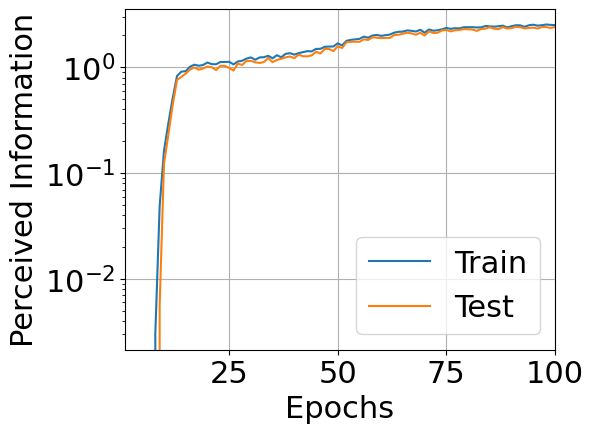

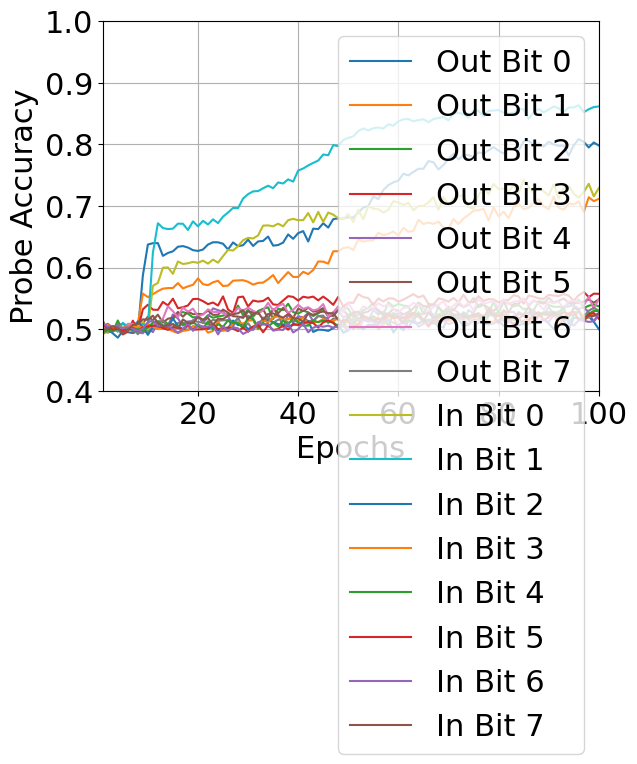

[[0.4971 0.4919 0.5024 ... 0.5068 0.5096 0.4982]
 [0.4998 0.4964 0.5001 ... 0.5013 0.5036 0.5009]
 [0.4975 0.5008 0.4958 ... 0.4996 0.5049 0.5045]
 ...
 [0.7948 0.714  0.538  ... 0.5238 0.5117 0.5215]
 [0.803  0.7077 0.5397 ... 0.5262 0.5127 0.5213]
 [0.798  0.7115 0.5371 ... 0.5169 0.5248 0.526 ]]


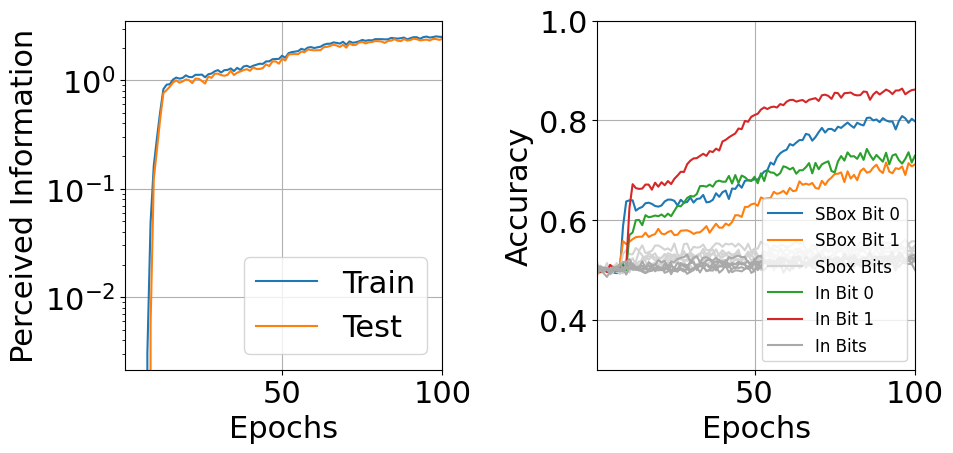

In [ ]:
import gc
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.plot(range(1, 101), pi_prof, label="Train")
plt.plot(range(1, 101), pi_attack, label="Test")


plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Perceived Information")
plt.xlim([1,100])
plt.grid()
plt.legend()
plt.subplot(1,2,2)
print(probe_total)
for i in range(16):
    if i % 8 < 2:
        if i > 7:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], label=f"In Bit {i%8}")
        else:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], label=f"SBox Bit {i%8}")
    
    else:
        if i ==2:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], color='lightgrey', label="Sbox Bits")
        elif i < 8:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], color='lightgrey')
        elif i == 10:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], color='darkgrey', label="In Bits")
        else:
            plt.plot(range(1, 101), probe_total[range(0, 100), i], color='darkgrey')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim([0.3, 1.0])
plt.grid()
plt.xlim([1, 100])
plt.legend(loc=4, prop={'size': 12})
plt.tight_layout()
plt.savefig("ascadr_cnn_pi_acc.png", dpi=100)


## Logit Visualization

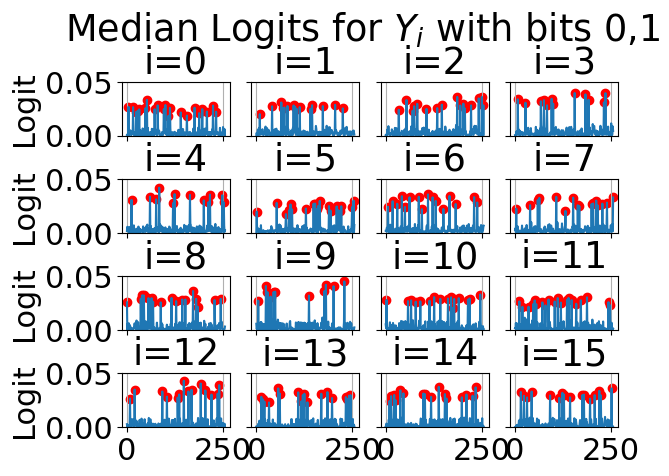

<Figure size 1600x800 with 0 Axes>

In [ ]:
import numpy as np

def visualize_logits(logits, labels,list_of_stuffs=None, num_classes=256):
    """
    Visualizes the logits for each class.

    Args:
        logits (np.ndarray): Logits array of shape (num_samples, num_classes).
        labels (np.ndarray): True labels corresponding to the logits.
        num_classes (int): Number of classes in the dataset.
    """
    # Adjust the top spacing to prevent overlap with the suptitle
    fig, axs =plt.subplots(4,4)
    fig.subplots_adjust(hspace=0.8)
    fig.subplots_adjust(top=0.83)  
    avg_logits = np.zeros((num_classes, logits.shape[1]))
    for i in range(16):
        avg_logits[i] = np.mean(logits[labels == i], axis=0)
        #out_logits.append(logits[9])
        axs[i//4, i%4].set_title(f"i={i}")
        axs[i//4, i%4].plot(avg_logits[i], label="Median Logits")
        axs[i//4, i%4].grid()
        axs[i//4, i%4].set_ylim([0, 0.05])
        if not list_of_stuffs is None:
            #axs[i//4, i%4].scatter(list_of_stuffs[i], avg_logits[list_of_stuffs[i]], label=f"Points $Y_{i}$", color='b')
            axs[i//4, i%4].scatter(list_of_stuffs[i], avg_logits[i][list_of_stuffs[i]], label=f"Points $Y_{i}$", color='r')
        


    for ax in axs.flat:
        ax.set(ylabel='Logit')
        # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()
    fig.suptitle(f"Median Logits for $Y_i$ with bits 0,1")
    #fig.tight_layout()
    # Plot the average logits
    plt.savefig("logits_CNN.png", dpi=200)
    plt.figure(figsize=(16, 8))
    
    plt.show()

def generate_logit_indices():
    list_of_stuffs = []
    for i in range(16):
        #ins, = np.where(out_logits[i] > 0.005)
        # print(i, ins)
        in_sboxes = []
        out_sboxes = []
        for j in range(256):
            if (j) % 4 == (i>>2):
                in_sboxes.append(aes_sbox[j])
            if (j) % 4 == i %4:
                out_sboxes.append(j)
        list_of_stuffs.append(np.sort(np.intersect1d(in_sboxes, out_sboxes)))
    return list_of_stuffs

# Example usage
logits = tmp_att[-1]  # Assuming logits are in tmp_att[layer]
labels = get_classes_bits(sbox_ins_att,bits=[0, 1])*4
labels += get_classes_bits(dataset.attack_labels, bits=[0, 1])
#labels = dataset.attack_labels  # Assuming labels are in dataset.attack_labels
visualize_logits(logits, labels,generate_logit_indices())

## PCA stuff


## Testing PCA/Bit divisions quickly

In [ ]:
from sklearn.decomposition import PCA
from utils import plot_pcs_with_class_divs, get_classes_bits
gc.collect()
reload_model(100)
layer=1
for layer in range(1, 15):
    classes = get_classes_bits(sbox_ins_att, bits=[0,1])
    x_prof = tmp[layer].reshape(tmp[layer].shape[0], -1)
    x = tmp_att[layer].reshape(tmp_att[layer].shape[0], -1)
    plot_pcs_with_class_divs(x_prof, classes,n_pcs=4, activations_attack=x, pcs_to_plot=[0,1])
    classes = get_classes_bits(dataset.attack_labels, bits=[ 0, 1])
    plot_pcs_with_class_divs(x_prof, classes,n_pcs=4, activations_attack=x, pcs_to_plot=[2,3])



## Messy code for plots from paper

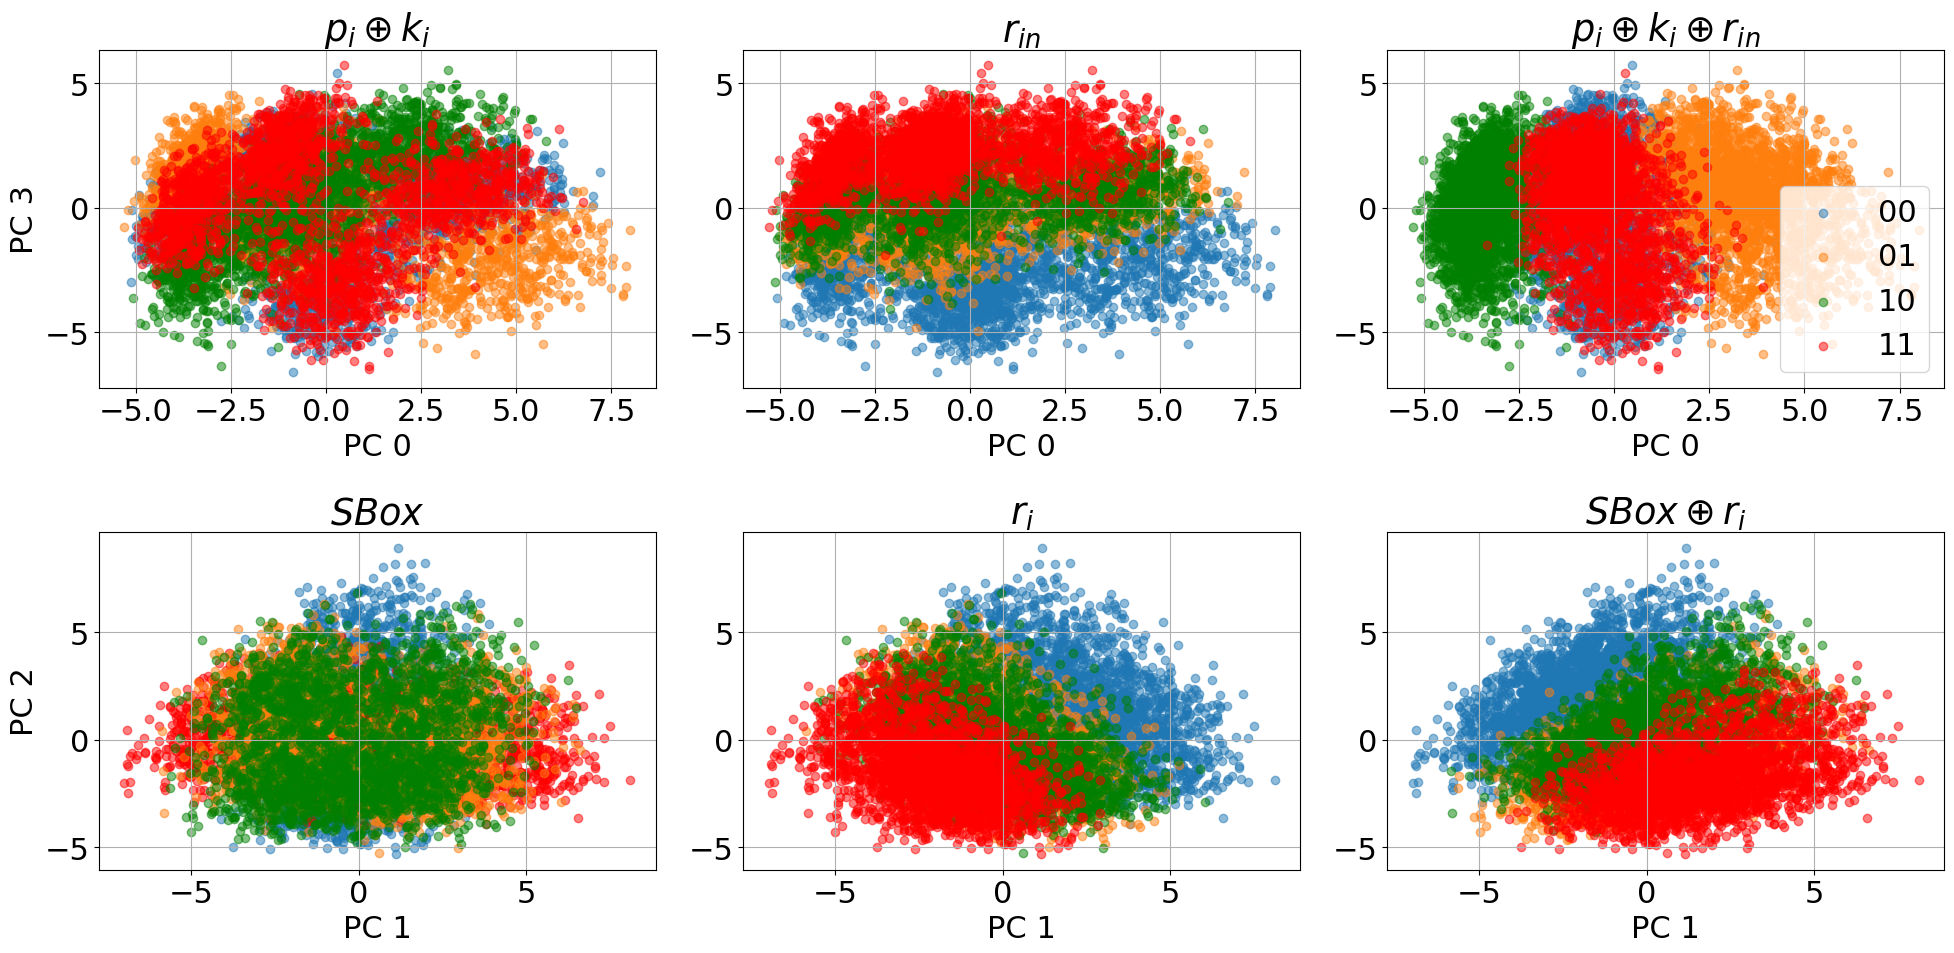

In [ ]:
import gc
gc.collect()
reload_model(100)
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^
                dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
font = {'size'   : 18}
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
# Prepare logits
out_logits = []
layer = 12

on = np.where(sbox_ins_att&0x3==0)
off = np.where(sbox_ins_att&0x3==1)
on2 = np.where(sbox_ins_att&0x3==2)
off3 = np.where(sbox_ins_att&0x3 ==3)
plt.figure(figsize=(20, 10))  # Adjust the figure size for 1x3 layout

labels = ["00", "01", "10", "11"]
indices_list= [on, off, on2, off3]
# Subplot 1: Logits
# PCA preparation
comp_n = 4
new_pca = PCA(n_components=comp_n)
layer = 9
new_s1_prof = new_pca.fit_transform(tmp[layer]. reshape(tmp[layer].shape[0], -1))
new_s1_att = new_pca.transform(tmp_att[layer].reshape(tmp_att[layer].shape[0], -1))

# Subplot 2: PC scatter plot for PC2 vs PC1
plt.subplot(2, 3, 1)
in1, in2 = 0, 3

plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()

plt.title("$p_i \oplus k_i$")

plt.subplot(2, 3, 2)
rin = dataset.share5_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$r_{in}$")

plt.subplot(2, 3, 3)
rin = dataset.share6_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$p_i \oplus k_i \oplus r_{in}$")
plt.legend(loc=4)
#plt.title("PCA Scatter (PC1 vs PC0)")
#reload_model(25)

on = np.where(dataset.attack_labels&0x3==0)
off = np.where(dataset.attack_labels&0x3==1)
on2 = np.where(dataset.attack_labels&0x3==2)
off3 = np.where(dataset.attack_labels&0x3 ==3)
labels = ["00", "01", "10", "11"]
indices_list= [on, off, on2, off3]
comp_n = 4
new_pca = PCA(n_components=comp_n)
layer = 12
plt.subplot(2, 3, 4)
in1, in2 = 1, 2



plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()

plt.title("$SBox$")

# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 3, 5)
rin = dataset.share1_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$r_i$")

plt.subplot(2, 3, 6)
rin = dataset.share2_attack[target_byte].astype(np.uint8)
on = np.where(rin&0x3==0)
off = np.where(rin&0x3==1)
on2 = np.where(rin&0x3==2)
off3 = np.where(rin&0x3 ==3)
plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, in1], new_s1_att[on2, in2] ,c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, in1], new_s1_att[off3, in2], c='r', label="11", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("$SBox \oplus r_i$")




# Save or show the combined plot
plt.tight_layout()
plt.savefig(f"combined_plots_ascadr_lowest_cnn.png", dpi=20)
plt.savefig(f"combined_plots_ascad_lower_cnn.png", dpi=100)
plt.savefig(f"combined_plots_ascad_cnn.png", dpi=200)
plt.show()

## Activation Patching